# NYS Donate Life

# Reseach Question

How can New York State identify and prioritize communities at risk of low organ donor registration to support equity-centered outreach and resource allocation?

#### Dataset
https://health.data.ny.gov/Health/New-York-State-Donate-Life-Registry-Enrollment-by-/gvq6-s8vf/about_data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle

In [118]:
donate_df = pd.read_csv('New_York_State_Donate_Life_Registry_Enrollment_by_Zip_Code_20260228.csv', low_memory=False)

### data cleaning

In [3]:
# replace all commas in `Registry Enrollments` col with nothing
donate_df['Registry Enrollments'] = donate_df['Registry Enrollments'].str.replace(',', '')

In [4]:
# convert `Registry Enrollments` col into a float
donate_df["Registry Enrollments"] = pd.to_numeric(donate_df["Registry Enrollments"], downcast="float")

In [5]:
donate_df.describe()

,Zip Code,Year,Month,Registry Enrollments
count,159711.000000,159711.000000,159711.000000,159711.000000
mean,12331.583642,2016.707190,6.562666,42.653755
std,1442.246555,4.995214,3.416615,40.572071
min,7310.000000,2008.000000,1.000000,10.000000
25%,11218.000000,2012.000000,4.000000,17.000000
50%,12053.000000,2017.000000,7.000000,29.000000
75%,13619.000000,2021.000000,10.000000,53.000000
max,14905.000000,2026.000000,12.000000,1104.000000


# 1️⃣ `donate_df`
- num rows = 159,711 (one row per month, per year, per zip code)
- column = 4
    - `Zip Code` range: 7310 – 14905 (typo @ min?)
        - unique = 1,331
    - `Year` range: 2008 - 2026 (19 years)
    - `Month`range: 1-12
    - `Registry Enrollments` range: 10 – 1,104

to do:
- aggregate all months of year by zipcode to see trends over years 2008-2026
- see which zip codes de/increased enrollment over time

@ first glance: 
- (1) zip codes with high enrolment per month & year are in Manhattan 10021 UES, 10025 UWS/Morningside Heights, 10024 UWS, 10023 UWS;
- (2) only 1 in Brooklyn 11215. 
- What would aggregate data show?
  

In [6]:
donate_df.describe()

,Zip Code,Year,Month,Registry Enrollments
count,159711.000000,159711.000000,159711.000000,159711.000000
mean,12331.583642,2016.707190,6.562666,42.653755
std,1442.246555,4.995214,3.416615,40.572071
min,7310.000000,2008.000000,1.000000,10.000000
25%,11218.000000,2012.000000,4.000000,17.000000
50%,12053.000000,2017.000000,7.000000,29.000000
75%,13619.000000,2021.000000,10.000000,53.000000
max,14905.000000,2026.000000,12.000000,1104.000000


In [7]:
donate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159711 entries, 0 to 159710
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Zip Code              159711 non-null  int64  
 1   Year                  159711 non-null  int64  
 2   Month                 159711 non-null  int64  
 3   Registry Enrollments  159711 non-null  float32
dtypes: float32(1), int64(3)
memory usage: 4.3 MB


In [8]:
donate_df.nunique()

Zip Code                1331
Year                      19
Month                     12
Registry Enrollments     425
dtype: int64

# 2️⃣ `yearly_df`
- aggregate by month & year
- num rows = 18,230 (one row per zip code, per year)
- cols = 3
    - `Zip Code` range: 7310 – 14905 (typo @ min?) --> min = 10001
        - unique 1,331
    - `Year` range: 2008 - 2026 (19 years)
    - `Registry Enrollments` range: 10 – 4,063

In [9]:
# aggregate data by month & year
yearly_df = (
    donate_df
    .groupby(["Zip Code", "Year"], as_index=False)
    .agg({
        "Registry Enrollments": "sum"}))

In [10]:
yearly_df.head().sort_values('Zip Code', ascending=True )

,Zip Code,Year,Registry Enrollments
0,7310,2016,10.0
1,10001,2008,167.0
2,10001,2009,709.0
3,10001,2010,759.0
4,10001,2011,788.0


In [11]:
yearly_df.describe()

,Zip Code,Year,Registry Enrollments
count,18230.000000,18230.000000,18230.000000
mean,12490.679759,2016.521503,373.684814
std,1419.360124,5.151046,436.441956
min,7310.000000,2008.000000,10.000000
25%,11368.000000,2012.000000,70.000000
50%,12443.000000,2017.000000,231.000000
75%,13743.000000,2021.000000,507.000000
max,14905.000000,2026.000000,4063.000000


In [12]:
yearly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18230 entries, 0 to 18229
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Zip Code              18230 non-null  int64  
 1   Year                  18230 non-null  int64  
 2   Registry Enrollments  18230 non-null  float32
dtypes: float32(1), int64(2)
memory usage: 356.2 KB


In [13]:
yearly_df.nunique()

Zip Code                1331
Year                      19
Registry Enrollments    1833
dtype: int64

# 3️⃣ `yearly_totals`
- see data in table format
- num rows = 18 (one row per year)
- cols = 2
    - `Year` range: 2008 – 2026 (19 years)
    - `Registry Enrollments` range: 26 - 576,909

@ first glance:
- start of data collection (2008) lowest num enrollment (62797), lack of interest, lack of data collection?
- YTD (Feb 2026) low enrollment (96)

In [14]:
# see data in table format
yearly_totals = (
    yearly_df
    .groupby("Year", as_index=False)
    .agg({"Registry Enrollments": "sum"})
    .sort_values("Year")
)
yearly_totals

,Year,Registry Enrollments
0,2008,62797.0
1,2009,453728.0
2,2010,449287.0
3,2011,486162.0
4,2012,499021.0
5,2013,280256.0
6,2014,230767.0
7,2015,324444.0
8,2016,403212.0
9,2017,576909.0


In [15]:
yearly_totals.describe()

,Year,Registry Enrollments
count,19.000000,19.00000
mean,2017.000000,358540.75000
std,5.627314,155961.84375
min,2008.000000,96.00000
25%,2012.500000,298627.50000
50%,2017.000000,342261.00000
75%,2021.500000,469945.00000
max,2026.000000,576909.00000


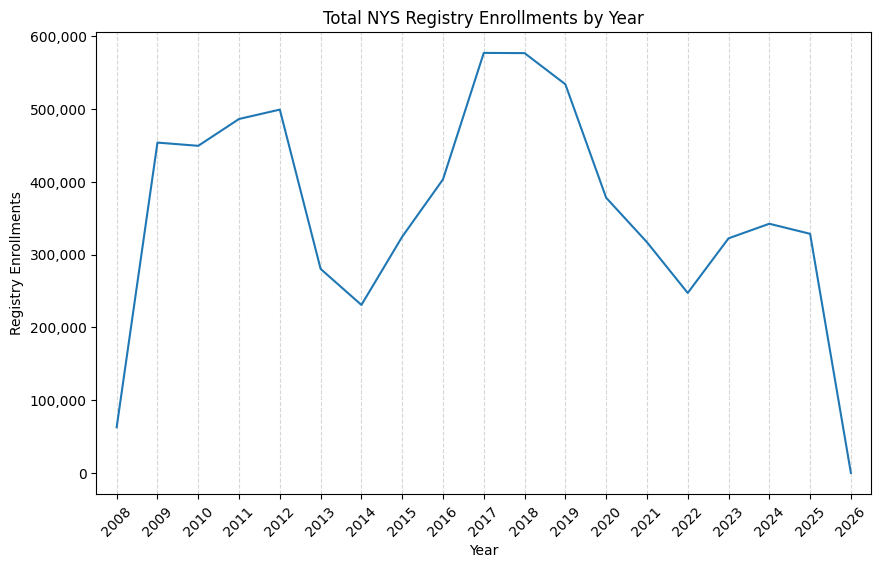

In [31]:
# visualize `yearly_totals_df`

plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_totals,
    x="Year",
    y="Registry Enrollments"
)

plt.xlim(2007.5, 2026.5)
plt.xticks(np.arange(2008, 2027, 1))
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.title("Total NYS Registry Enrollments by Year")
plt.xlabel("Year")
# plt.ylabel("Total Enrollments")
plt.show()

In [125]:
## pickle donate_df yearly_df yearly_totals
donate_df.to_pickle("donate_df.pkl")
yearly_df.to_pickle("yearly_df.pkl")
yearly_totals.to_pickle("yearly_totals.pkl")

In [126]:
## pickle donate_df yearly_df yearly_totals

with open("donate_df.pkl", "rb") as f:
    donate_df = pickle.load(f)

with open("yearly_df.pkl", "rb") as f:
    yearly_df = pickle.load(f)

with open("yearly_totals.pkl", "rb") as f:
    yearly_totals = pickle.load(f)

## Visualize 2025 for each zip code? 
No, too many rows (1,011)

In [120]:
# look at 2025
df_2025 = yearly_df[yearly_df['Year'] == 2025].copy()
df_2025

,Zip Code,Year,Registry Enrollments
18,10001,2025,902.0
36,10002,2025,1370.0
54,10003,2025,1552.0
72,10004,2025,93.0
90,10005,2025,301.0
...,...,...,...
18157,14895,2025,216.0
18175,14901,2025,323.0
18193,14903,2025,168.0
18211,14904,2025,398.0


# Zip Code Data
Isolate NYC zip codes?

## zipcode_race_df 
https://www.nyc.gov/assets/planning/download/office/data-maps/nyc-population/census2000/sf1p11.xls 

In [112]:
zipcode_race_df = pd.read_excel('nyc_zip_codes.xls', header=6)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [113]:
zipcode_race_df = zipcode_race_df.drop(zip_race_df.index[0])
zipcode_race_df = zipcode_race_df.reset_index(drop=True)
zipcode_race_df

,Borough,ZIPCODES,Unnamed: 2,White,Black/ African American,American Indian and Alaska Native,Asian,Native Hawaiian and Other Pacific Islander,Some Other Race,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,Manhattan,10001.0,17310.0,9166.0,1439.0,38.0,2641.0,5.0,72.0,464.0,3485.0,9806.0
1,Manhattan,10002.0,84870.0,13371.0,5184.0,111.0,41658.0,20.0,272.0,1550.0,22704.0,32965.0
2,Manhattan,10003.0,53673.0,39367.0,2209.0,61.0,6447.0,56.0,238.0,1234.0,4061.0,31154.0
3,Manhattan,10004.0,1225.0,861.0,69.0,0.0,150.0,4.0,14.0,48.0,79.0,779.0
4,Manhattan,10005.0,884.0,559.0,28.0,0.0,202.0,0.0,4.0,26.0,65.0,562.0
...,...,...,...,...,...,...,...,...,...,...,...,...
199,Queens,11691.0,56184.0,12312.0,27681.0,168.0,884.0,13.0,526.0,1717.0,12883.0,19424.0
200,Queens,11692.0,15893.0,1625.0,10765.0,60.0,138.0,2.0,139.0,544.0,2620.0,5656.0
201,Queens,11693.0,11157.0,5883.0,3117.0,21.0,218.0,0.0,49.0,247.0,1622.0,4607.0
202,Queens,11694.0,19278.0,15855.0,1109.0,18.0,438.0,6.0,19.0,169.0,1664.0,9038.0


In [114]:
zipcode_race_df.columns

Index(['Borough', 'ZIPCODES', 'Unnamed: 2', 'White',
       '   Black/ African American', '     American Indian and Alaska Native',
       '      Asian', 'Native Hawaiian and Other Pacific Islander',
       '  Some Other Race', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')

In [115]:
# rename columns
zipcode_race_df.rename(columns={'Borough': 'boro',
           'ZIPCODES': 'zip_code', 
           'Unnamed: 2': 'pop_total' ,
           'White': 'white',
           '   Black/ African American': 'black',
           '     American Indian and Alaska Native': 'native',
           '      Asian' : 'asian',
           'Native Hawaiian and Other Pacific Islander':'pacific_islander',
           '  Some Other Race': 'other_race',
            'Unnamed: 9': 'non_hispanic',
           'Unnamed: 10': 'hispanic',
           'Unnamed: 11': 'total_housing_units'}, inplace=True)

## zipcode_df

In [116]:
zipcode_df = zipcode_race_df[['boro', 'zip_code', 'total_housing_units']]

In [117]:
zipcode_df

,boro,zip_code,total_housing_units
0,Manhattan,10001.0,9806.0
1,Manhattan,10002.0,32965.0
2,Manhattan,10003.0,31154.0
3,Manhattan,10004.0,779.0
4,Manhattan,10005.0,562.0
...,...,...,...
199,Queens,11691.0,19424.0
200,Queens,11692.0,5656.0
201,Queens,11693.0,4607.0
202,Queens,11694.0,9038.0


In [128]:
# pickle zipcode_race_df zipcode_df
zipcode_race_df.to_pickle("zipcode_race_df.pkl")
zipcode_df.to_pickle("zipcode_df.pkl")

In [129]:
# # unpickle zipcode_race_df zipcode_df

# with open("zipcode_race_df.pkl", "rb") as f:
#     zipcode_race_df = pickle.load(f)

# with open("zipcode_df.pkl", "rb") as f:
#     zipcode_df = pickle.load(f)

# 🔖 use zip code and borough data with original data set